In [174]:
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import pandas as pd
from google.colab import drive
from scipy.signal import savgol_filter
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [200]:
data_ruta = "/content/drive/MyDrive/Labo 6 y 7 - Grupo 4/Mediciones en temperatura/01-09/PSS_plasma_1234_01-09-26/_01-09-26_Control Temperatura.txt"
datos = pd.read_csv(data_ruta,sep="\t")
filtro = (datos["Rrem2 (Ohm)"] > 0) & (datos["Rrem1 (Ohm)"] < 3e7)
datos = datos[filtro]
datos.head()

,Tiempo (s),Setpoint (K),Temperatura (K),dT/dt (K/min),Potencia_LS (%),Rrem1 (Ohm),std Rrem1 (Ohm),Rrem2 (Ohm),Unnamed: 8,std Rrem2 (Ohm),V4W (V),Unnamed: 11
0,38.173183E+0,298.470000,298.47,NaN,3.0,1008079.000,1008079.000,1575.307,1575.307,0.986829,NaN,NaN
1,43.637496E+0,298.470000,298.47,NaN,5.0,1110937.000,1110937.000,203800.354,203800.354,0.990323,NaN,NaN
2,49.623838E+0,298.652144,298.47,NaN,5.0,2568458.000,2568458.000,483763.754,483763.754,1.015440,NaN,NaN
3,55.100152E+0,298.851688,298.47,NaN,6.0,911583.043,911583.043,164533.838,164533.838,0.997992,NaN,NaN
4,60.584466E+0,299.000000,298.47,NaN,9.0,738316.186,738316.186,136648.292,136648.292,0.992452,NaN,NaN


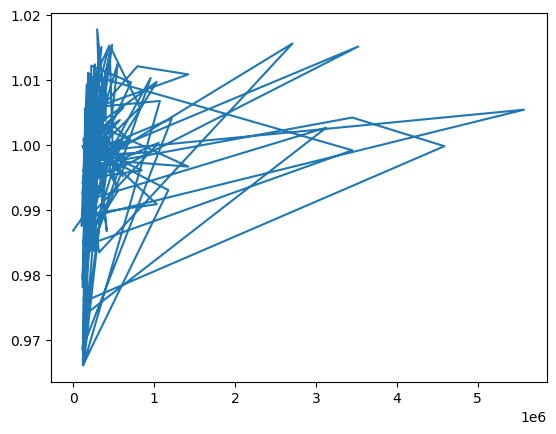

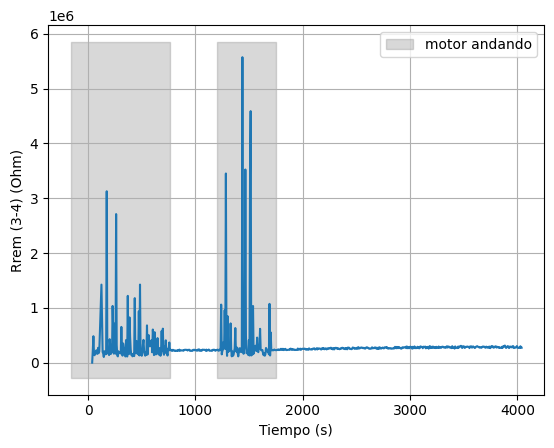

127


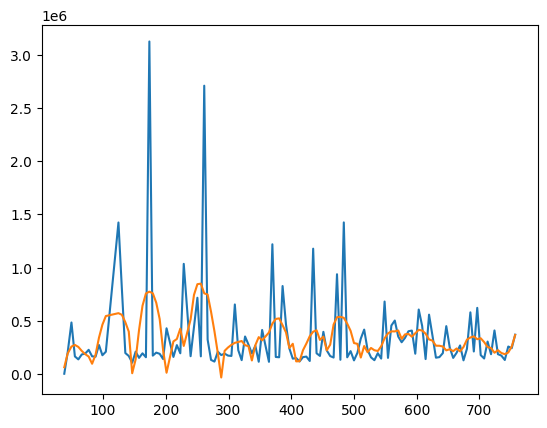

80


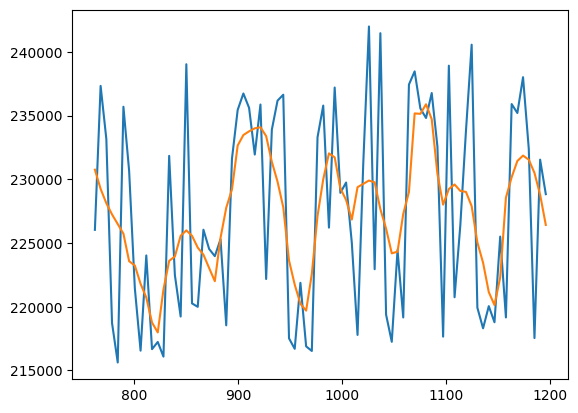

100


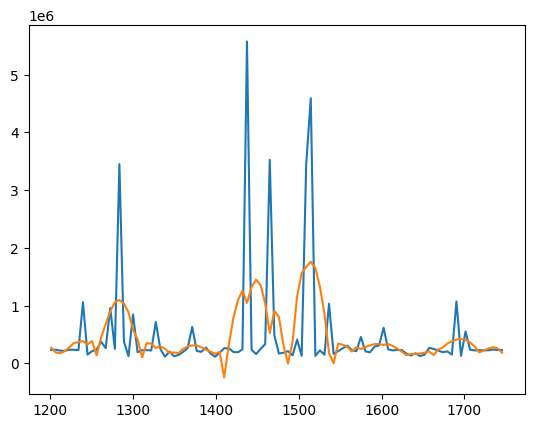

416


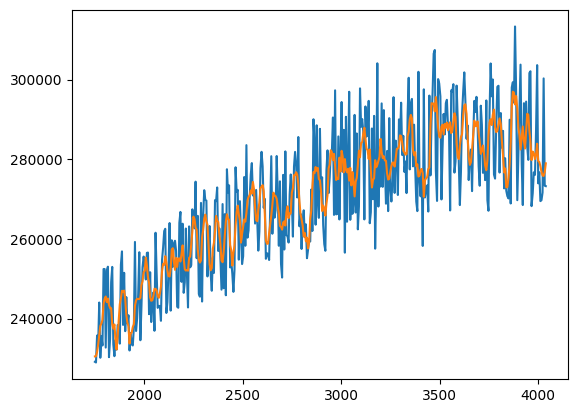

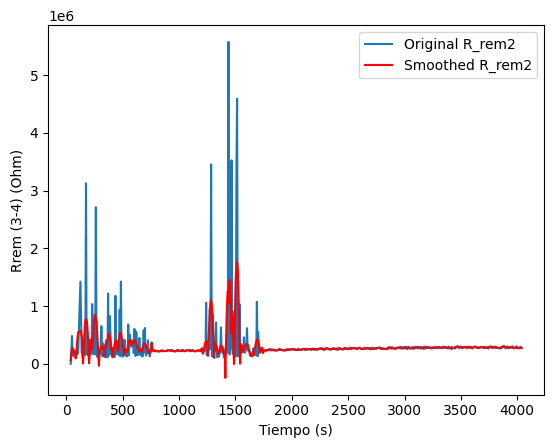

In [283]:
T = datos["Temperatura (K)"]
t = pd.to_numeric(datos["Tiempo (s)"])
R_rem1 = datos["Rrem1 (Ohm)"]
R_rem2 = datos["Rrem2 (Ohm)"]
# R_rem2 = R_rem1
sigma = datos["std Rrem2 (Ohm)"]
Potencia = datos["Potencia_LS (%)"]

plt.plot(R_rem2, sigma)
plt.show()

plt.plot(t,R_rem2)
# plt.axvline(760)
# plt.axvline(1200)
# plt.axvline(1750)
plt.xlabel("Tiempo (s)")
plt.ylabel("Rrem (3-4) (Ohm)")

# Get current x and y limits to fill the entire vertical space
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# Fill the regions using plt.fill_between for vertical shading
# Region 1: from xmin to 760
plt.fill_between([xmin, 760], ymin, ymax, color="grey", alpha=0.3,label ="motor andando")
# Region 2: from 1200 to 1750
plt.fill_between([1200, 1750], ymin, ymax, color="grey", alpha=0.3)
plt.grid()
plt.legend()
plt.show()

mask_1 = (t < 760)
mask_med = (t > 760) & (t < 1200)
mask_2 = (t > 1200)  & (t < 1750)
mask_med_2 = (t > 1750)

mascaras = [mask_1,mask_med,mask_2,mask_med_2]
R_rem_filtrado = []

# Create an empty Series to store the full smoothed data, matching the index of t
smoothed_full_R_rem2 = pd.Series(index=t.index, dtype=float)

for mask in mascaras:
  t_f = t[mask]
  R_rem1_f = R_rem1[mask]
  R_rem2_f = R_rem2[mask]
  print(len(t_f))
  window_size = 11
  poly_order = 3

  # Ensure window_length is odd and less than or equal to the number of points
  current_window_size = min(window_size, len(t_f) // 2 * 2 + 1) # make it odd and max len(t_f)
  if current_window_size < poly_order + 1:
    # If not enough points for smoothing, skip or handle appropriately
    print(f"Skipping smoothing for a segment with {len(t_f)} points, not enough for window_size={window_size} and poly_order={poly_order}")
    Rre2_smooth = R_rem2_f.values # Use original values if cannot smooth
  else:
    Rre2_smooth = savgol_filter(R_rem2_f, window_length=current_window_size, polyorder=poly_order)

  R_rem_filtrado.append(Rre2_smooth)

  # Assign the smoothed values back to the correct positions in the full series
  smoothed_full_R_rem2[t_f.index] = Rre2_smooth

  #plt.plot(t_f,R_rem1_f)
  plt.plot(t_f,R_rem2_f)
  plt.plot(t_f,Rre2_smooth)

  plt.show()


plt.plot(t,R_rem2, label='Original R_rem2')
plt.plot(t,smoothed_full_R_rem2, label='Smoothed R_rem2', color='red')
plt.xlabel("Tiempo (s)")
plt.ylabel("Rrem (3-4) (Ohm)")
plt.legend()
plt.show()

[   1857.29373689 -215763.85976008]
[[ 2.14727450e+05 -6.03285325e+07]
 [-6.03285325e+07  1.69965204e+10]]


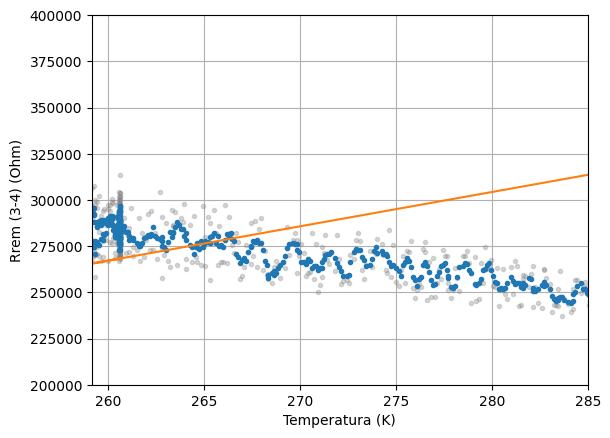

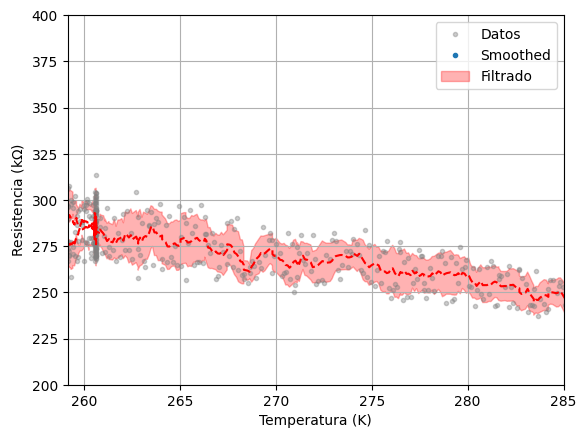

In [284]:
popt,pcov = np.polyfit(T,smoothed_full_R_rem2,1,cov=True)
print(popt)
print(pcov)

plt.plot(T,R_rem2,".",alpha = 0.3,color="grey")
plt.plot(T,smoothed_full_R_rem2,".")
plt.plot(T,popt[0]*T+popt[1])
plt.xlabel("Temperatura (K)")
plt.ylabel("Rrem (3-4) (Ohm)")
plt.ylim(0.2e6,0.4e6)
plt.xlim(min(T),285)
plt.grid()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convertir a Series de Pandas para calcular la media y error móvil
s_smoothed = pd.Series(R_rem2)

# Promedio móvil centrado de 5 puntos
smoothed_win5 = s_smoothed.rolling(window=10, center=True, min_periods=1).mean().to_numpy()

# Desviación estándar (error) dentro de la misma ventana de 5 puntos
error_win5 = s_smoothed.rolling(window=10, center=True, min_periods=1).std().fillna(0).to_numpy()


# 2. Gráfico
plt.plot(T, R_rem2/1e3, ".", alpha=0.4, color="grey", label="Datos")
plt.plot(T, smoothed_full_R_rem2, ".", label="Smoothed")

#Nuevo suavizado de 5 puntos con su banda de error
plt.plot(T, smoothed_win5/1e3, "--", color="red")
plt.fill_between(T, (smoothed_win5 - error_win5)*1e-3, (smoothed_win5 + error_win5)*1e-3,
                 color="red", alpha=0.3, label="Filtrado")

plt.xlabel("Temperatura (K)")
plt.ylabel("Resistencia (k$\\Omega$)")
plt.ylim(0.2e3, 0.4e3)
plt.xlim(min(T), 285)
plt.grid()
plt.legend()
plt.show()

Parámetros (m, b): [ -1.37157005 640.29729256]
Matriz de covarianza:
 [[ 4.22633759e-04 -1.15426330e-01]
 [-1.15426330e-01  3.15498764e+01]]


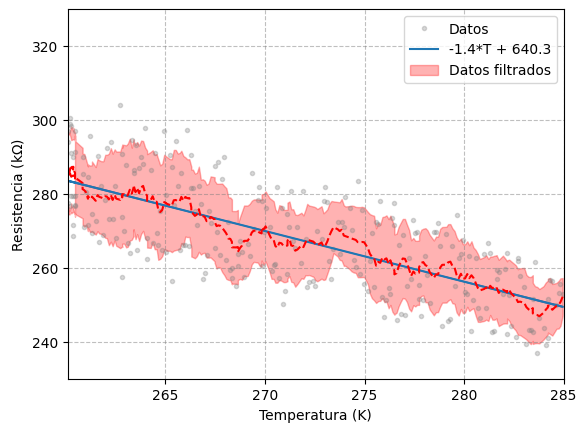

In [336]:
import numpy as np
import matplotlib.pyplot as plt

# Convertimos a arreglos de numpy si no lo son
# T and R_rem2 are Series from previous cells, convert them to numpy arrays.
T_as_np = np.array(T)
R_rem2_as_np = np.array(R_rem2)

# Create the boolean mask for the initial temperature condition using the full T array
mask_initial_temp_condition = (T_as_np <= 285) & (T_as_np >= 260)

# Apply this mask to both T and R_rem2 to filter them consistently
T = T_as_np[mask_initial_temp_condition]
R_rem2 = R_rem2_as_np[mask_initial_temp_condition]

# R_rem should now simply refer to the filtered R_rem2
R_rem = R_rem2

# Definimos el rango exacto de la temperatura que queremos eliminar
# (Ajusta 260.5 y 260.7 según el valor exacto que ves en tus datos)
mask_exclusion = ~((T >= 260.5) & (T <= 260.7) )

# Aplicamos el filtro a ambos vectores
T_filtrado = T[mask_exclusion]
R_rem2_filtrado = R_rem2[mask_exclusion]


# 1. Convertir a Series de Pandas para calcular la media y error móvil
s_smoothed = pd.Series(R_rem2_filtrado)

# Promedio móvil centrado de 5 puntos
smoothed_win5 = s_smoothed.rolling(window=15, center=True, min_periods=1).mean().to_numpy()

# Desviación estándar (error) dentro de la misma ventana de 5 puntos
error_win5 = s_smoothed.rolling(window=15, center=True, min_periods=1).std().fillna(0).to_numpy()

popt, pcov = np.polyfit(T_filtrado, smoothed_win5/1e3, 1, cov=True, w = 1/error_win5 )
print("Parámetros (m, b):", popt)
print("Matriz de covarianza:\n", pcov)

# 1. Extraemos varianzas y covarianza
var_m = pcov[0, 0]
var_b = pcov[1, 1]
cov_mb = pcov[0, 1]

# 2. Calculamos el error propagado sobre el ajuste lineal usando T (Temperatura)
sigma_y = np.sqrt((T_filtrado**2) * var_m + var_b + 2 * T_filtrado * cov_mb)


# Graficamos los datos limpios
plt.plot(T_filtrado, R_rem2_filtrado/1e3, ".", alpha=0.3, color="grey", label="Datos")
plt.plot(T_filtrado, np.polyval(popt, T_filtrado), label=f"{round(popt[0],1)}*T + {round(popt[1],1)}")
plt.fill_between(T_filtrado, np.polyval(popt, T_filtrado) - sigma_y, np.polyval(popt, T_filtrado) + sigma_y)
plt.plot(T_filtrado, smoothed_win5/1e3, "--", color="red")
plt.fill_between(T_filtrado, (smoothed_win5 - error_win5)*1e-3, (smoothed_win5 + error_win5)*1e-3,
                 color="red", alpha=0.3,label = "Datos filtrados")


plt.xlabel("Temperatura (K)")
plt.ylabel("Resistencia (k$\\Omega$)")
plt.ylim(0.23e3, 0.33e3)
plt.xlim(min(T), 285)
plt.legend()
plt.grid(linestyle = "--",color ="grey",alpha = 0.5)
plt.show()

In [178]:
data_ruta = "/content/drive/MyDrive/Labo 6 y 7 - Grupo 4/Mediciones en temperatura/01-09/PSS_plasma_01-09-26c/_01-09-26_Control Temperatura.txt"
datos = pd.read_csv(data_ruta,sep="\t")
filtro = (datos["Rrem2 (Ohm)"] > 0) & (datos["Rrem1 (Ohm)"] < 3e7)
datos = datos[filtro]
datos.head()

,Tiempo (s),Setpoint (K),Temperatura (K),dT/dt (K/min),Potencia_LS (%),Rrem1 (Ohm),std Rrem1 (Ohm),Rrem2 (Ohm),Unnamed: 8,std Rrem2 (Ohm),V4W (V),Unnamed: 11
0,26.838535,260.651355,260.56,0.0,27.0,2088080.0,2088080.0,286102.934,286102.934,1.000086,NaN,NaN
1,32.313848,260.651355,260.64,0.0,41.0,2304755.0,2304755.0,615383.729,615383.729,1.000033,NaN,NaN
2,37.755160,260.742610,260.64,0.0,43.0,2260171.0,2260171.0,584055.924,584055.924,0.999877,NaN,NaN
3,43.209472,260.833299,260.64,0.0,41.0,2104189.0,2104189.0,547010.704,547010.704,1.000605,NaN,NaN
4,48.686785,260.924204,260.64,0.0,45.0,2194046.0,2194046.0,567007.945,567007.945,0.999695,NaN,NaN


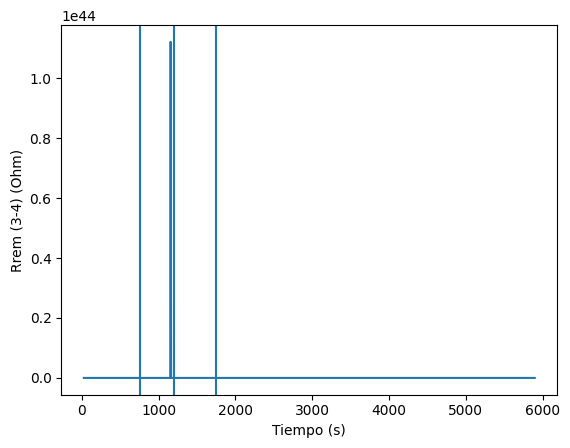

102


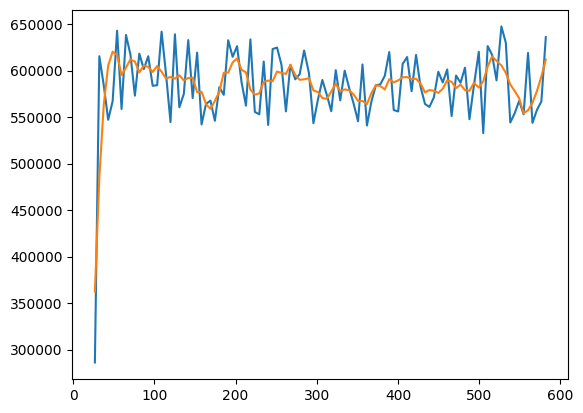

9


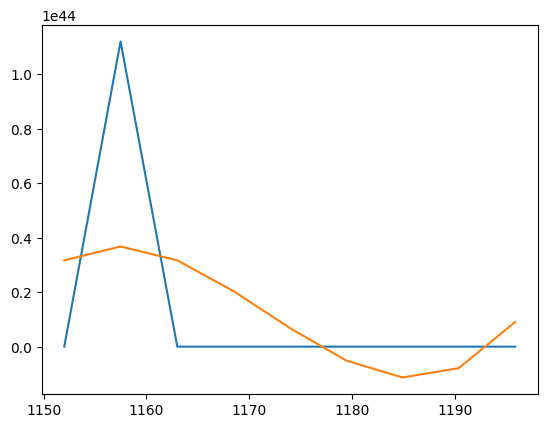

101


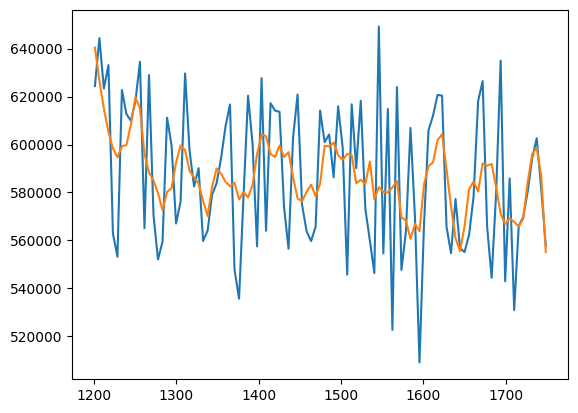

640


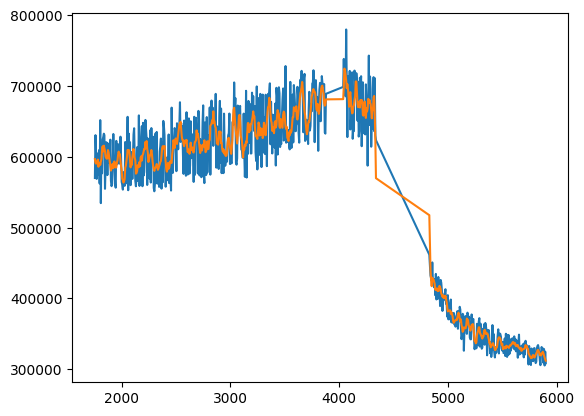

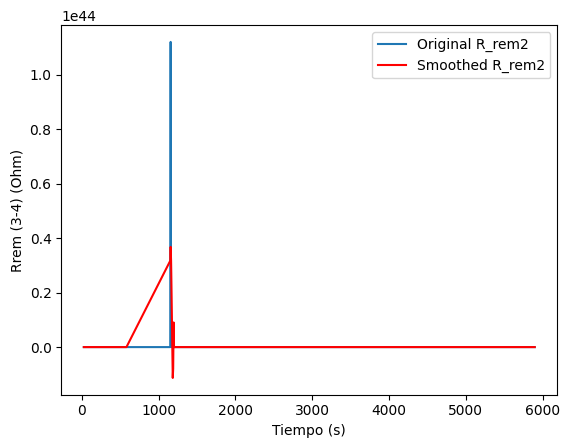

In [179]:
T_subida = datos["Temperatura (K)"]
t = pd.to_numeric(datos["Tiempo (s)"])
R_rem1 = datos["Rrem1 (Ohm)"]
R_rem2_subida = datos["Rrem2 (Ohm)"]
# R_rem2_subida = R_rem1
Pot_subida = datos["Potencia_LS (%)"]

plt.plot(t,R_rem2_subida)
plt.axvline(760)
plt.axvline(1200)
plt.axvline(1750)
plt.xlabel("Tiempo (s)")
plt.ylabel("Rrem (3-4) (Ohm)")
plt.show()

mask_1 = (t < 760)
mask_med = (t > 760) & (t < 1200)
mask_2 = (t > 1200)  & (t < 1750)
mask_med_2 = (t > 1750)

mascaras = [mask_1,mask_med,mask_2,mask_med_2]
R_rem_filtrado = []

# Create an empty Series to store the full smoothed data, matching the index of t
smoothed_full_R_rem2_subida = pd.Series(index=t.index, dtype=float)

for mask in mascaras:
  t_f = t[mask]
  R_rem1_f = R_rem1[mask]
  R_rem2_f = R_rem2_subida[mask]
  print(len(t_f))
  window_size = 11
  poly_order = 3

  # Ensure window_length is odd and less than or equal to the number of points
  current_window_size = min(window_size, len(t_f) // 2 * 2 + 1) # make it odd and max len(t_f)
  if current_window_size < poly_order + 1:
    # If not enough points for smoothing, skip or handle appropriately
    print(f"Skipping smoothing for a segment with {len(t_f)} points, not enough for window_size={window_size} and poly_order={poly_order}")
    Rre2_smooth = R_rem2_subida.values # Use original values if cannot smooth
  else:
    Rre2_smooth = savgol_filter(R_rem2_f, window_length=current_window_size, polyorder=poly_order)

  R_rem_filtrado.append(Rre2_smooth)

  # Assign the smoothed values back to the correct positions in the full series
  smoothed_full_R_rem2_subida[t_f.index] = Rre2_smooth

  #plt.plot(t_f,R_rem1_f)
  plt.plot(t_f,R_rem2_f)
  plt.plot(t_f,Rre2_smooth)

  plt.show()


plt.plot(t,R_rem2_subida, label='Original R_rem2')
plt.plot(t,smoothed_full_R_rem2_subida, label='Smoothed R_rem2', color='red')
plt.xlabel("Tiempo (s)")
plt.ylabel("Rrem (3-4) (Ohm)")
plt.legend()
plt.show()

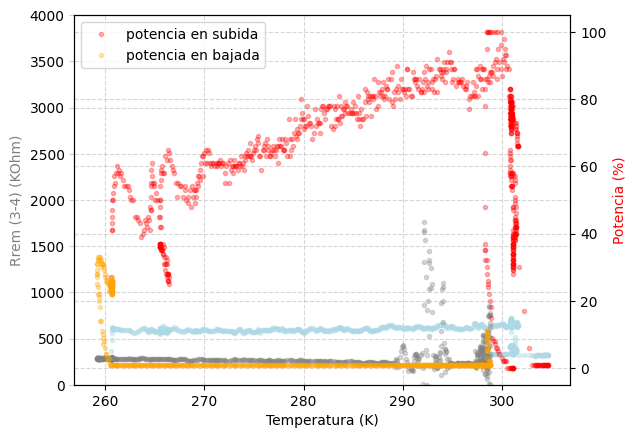

In [180]:
fig, ax1 = plt.subplots()
ax1.plot(T_subida,smoothed_full_R_rem2_subida/1e3,".",alpha = 0.4,color="lightblue")
ax1.set_xlabel("Temperatura (K)")
ax1.set_ylabel("Rrem (3-4) (KOhm)", color="grey")
ax1.set_ylim(0,4e3)
ax1.tick_params(axis="y", color="lightblue")

ax1.plot(T,smoothed_full_R_rem2/1e3,".",alpha = 0.3,color="grey")


ax2 = ax1.twinx()
ax2.plot(T_subida,Pot_subida,".",alpha = 0.3,color="red",label = "potencia en subida")
ax2.plot(T,Potencia,".",alpha = 0.3,color="orange",label = "potencia en bajada")
ax2.set_ylabel("Potencia (%)", color="red")

ax1.grid(linestyle = "--",alpha=0.5)
ax2.grid(linestyle = "--",alpha=0.5)
ax2.legend()
plt.show()

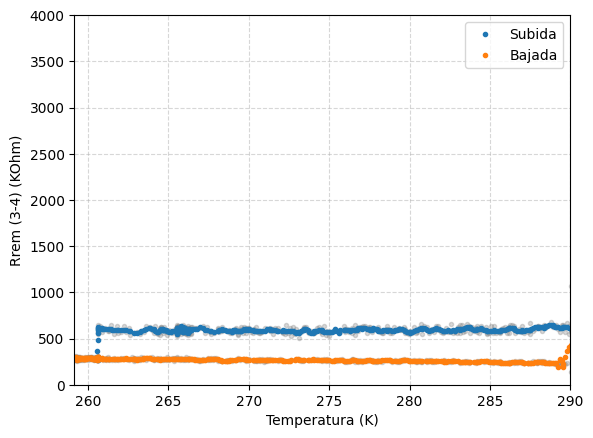

In [181]:
plt.plot(T_subida,R_rem2_subida/1e3,".",alpha = 0.3,color="grey")
plt.plot(T_subida,smoothed_full_R_rem2_subida/1e3,".",label = "Subida")

plt.plot(T,R_rem2/1e3,".",alpha = 0.3,color="grey")
plt.plot(T,smoothed_full_R_rem2/1e3,".",label = "Bajada")


plt.xlabel("Temperatura (K)")
plt.ylabel("Rrem (3-4) (KOhm)")
plt.ylim(0,4e3)
plt.xlim(min(T),290)
plt.grid(linestyle = "--",alpha=0.5)
plt.legend()
plt.show()

In [182]:
data_ruta = "/content/drive/MyDrive/Labo 6 y 7 - Grupo 4/Mediciones en temperatura/01-09/PSS_plasma_01-09-26c/265.txt"
datos = pd.read_csv(data_ruta,sep="\t")
datos = datos[filtro]
datos.head()

/tmp/ipykernel_2672/2566811014.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos = datos[filtro]


,Tiempo (min),T (K),I pulso(mA),Vinst 1 (V),Iinst 1 (mA),Rinst 1(Ohm),Rinst 2 (Ohm),Rrem 1 (Ohm),Rrem 2 (Ohm),Ibias 1 (mA),Vbias 1 (V),Ancho pulso (s),Periodo (s),Icc 1 (mA),Vcc 1 (V),Icc 2 (mA),Vcc 2 (V),Vp 4W (V),Vb 4W (V),N
0,0.019051,265.62,10.0,0.010487,-0.000009,-1208180.0,-3693894.0,1926839.0,291601.2,0.000519,1.000492,0.01,0.0,0.002,2.0,0.002,2.0,0.032063,0.151411,1.0
1,0.057437,265.62,-25.0,-0.025071,0.000009,-2653026.0,-2369524.0,2118721.0,594556.0,0.000472,1.000587,0.01,0.0,0.002,2.0,0.002,2.0,-0.022392,0.280785,2.0
2,0.095972,265.62,-50.0,-0.050076,-0.000007,7407722.0,2034497.0,2342333.0,715345.9,0.000427,0.999614,0.01,0.0,0.002,2.0,0.002,2.0,-0.013753,0.305281,3.0
3,0.134341,265.62,-75.0,-0.075120,-0.000033,2253816.0,216753.7,2152862.0,627989.3,0.000465,1.000155,0.01,0.0,0.002,2.0,0.002,2.0,-0.007224,0.291745,4.0
4,0.172460,265.62,-100.0,-0.100021,-0.000061,1651883.0,184262.6,2128413.0,544280.6,0.000470,1.000503,0.01,0.0,0.002,2.0,0.002,2.0,-0.011157,0.255850,5.0


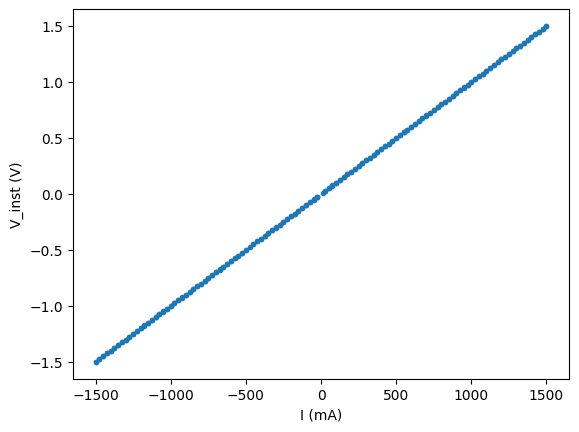

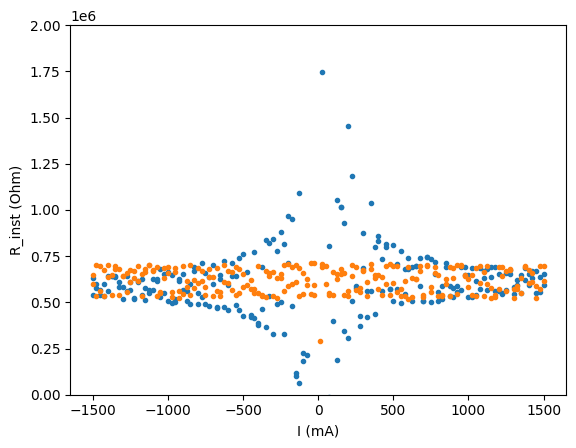

In [183]:
I = datos['I pulso(mA)']
V_inst = datos['Vinst 1 (V)']
R_inst_1 = datos['Rinst 1(Ohm)']
R_inst_2 = datos['Rinst 2 (Ohm)']
R_rem_1 = datos['Rrem 1 (Ohm)']
R_rem_2 = datos['Rrem 2 (Ohm)']

plt.plot(I,V_inst,".")
plt.xlabel("I (mA)")
plt.ylabel("V_inst (V)")
plt.show()

plt.plot(I,R_inst_2,".")
plt.plot(I,R_rem_2,".")
plt.xlabel("I (mA)")
plt.ylabel("R_inst (Ohm)")
plt.ylim(0,2e6)
plt.show()